In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

# Load Dataset

In [4]:
Students = pd.read_csv(r"C:\Users\Dell\Downloads\student_info.csv")
Students

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19
...,...,...
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05


In [5]:
Students.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [6]:
Students.tail()

,study_hours,student_marks
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05
199,8.35,83.50


In [7]:
Students.isnull()

,study_hours,student_marks
0,False,False
1,False,False
2,True,False
3,False,False
4,False,False
...,...,...
195,False,False
196,False,False
197,False,False
198,False,False


In [8]:
Students.shape

(200, 2)

# Discover and visulize the data to gain insights 

In [9]:
Students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [10]:
Students.describe()

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


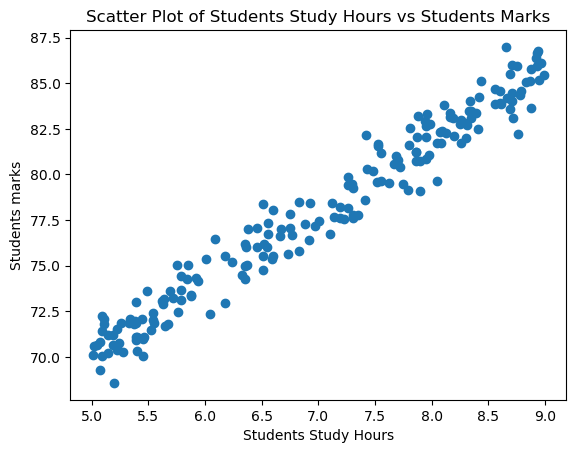

In [14]:
plt.scatter(x = Students.study_hours, y = Students.student_marks)
plt.xlabel("Students Study Hours")
plt.ylabel("Students marks")
plt.title("Scatter Plot of Students Study Hours vs Students Marks")
plt.show()

# Prepare the data for Machine Learning Algorithms

In [17]:
Students.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

In [18]:
Students.mean()

study_hours       6.995949
student_marks    77.933750
dtype: float64

In [19]:
Students2 = Students.fillna(Students.mean())

In [20]:
Students2.isnull().sum()

study_hours      0
student_marks    0
dtype: int64

In [21]:
Students2.head()

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19


In [22]:
Students2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    200 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [23]:
# Split dataset 
X = Students2.drop("student_marks",axis="columns")
y = Students2.drop("study_hours", axis="columns")
print("shape of x = ",X.shape)
print("shape of y = ", y.shape)

shape of x =  (200, 1)
shape of y =  (200, 1)


In [24]:
X

,study_hours
0,6.830000
1,6.560000
2,6.995949
3,5.670000
4,8.670000
...,...
195,7.530000
196,8.560000
197,8.940000
198,6.600000


In [25]:
y

,student_marks
0,78.50
1,76.74
2,78.68
3,71.82
4,84.19
...,...
195,81.67
196,84.68
197,86.75
198,78.05


In [26]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size =0.2,random_state=0)

print("shape of X_train = ",X_train.shape)
print("shape of y_train = ",y_train.shape)
print("shape of X_test = ",X_test.shape)
print("shape of y_test= ",y_test.shape)

shape of X_train =  (160, 1)
shape of y_train =  (160, 1)
shape of X_test =  (40, 1)
shape of y_test=  (40, 1)


In [27]:
X_train

,study_hours
134,6.51
66,7.86
26,6.51
113,7.95
168,7.95
...,...
67,8.26
192,8.71
117,8.83
47,5.01


# Select a model and train it 

In [31]:
# y = m * x + c
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
lr.coef_  #m

array([[3.93037294]])

In [38]:
lr.intercept_  #c

array([50.45063632])

In [39]:
m = 3.93
c = 50.44
y = m * 11 + c
y

93.67

In [40]:
m = 3.93 
c = 50.44
y = m * 10 + c
y 

89.74000000000001

In [42]:
lr.predict([[11]]).round(2)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[93.68]])

In [43]:
lr 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
 #lr.predict([[5]])[0][0].round(2)
y_pred = lr.predict(X_test)
y_pred

array([[83.50507271],
       [70.84927186],
       [72.93236952],
       [85.35234799],
       [73.20749562],
       [84.48766595],
       [80.12495199],
       [81.85431608],
       [80.91102657],
       [82.20804964],
       [78.98514384],
       [84.84139951],
       [77.84533568],
       [77.68812077],
       [83.22994661],
       [85.78468901],
       [84.9593107 ],
       [72.61793968],
       [78.71001773],
       [79.18166248],
       [84.2911473 ],
       [85.6274741 ],
       [74.74034107],
       [81.3433676 ],
       [72.02838374],
       [80.40007809],
       [78.98514384],
       [82.09013845],
       [77.94732382],
       [82.24735337],
       [75.44780819],
       [84.60557713],
       [71.63534645],
       [75.48711192],
       [70.29901965],
       [78.98514384],
       [75.32989701],
       [84.52696967],
       [74.07217767],
       [71.4388278 ]])

In [52]:
pd.DataFrame(np.c_[X_test,y_test,y_pred],columns=["study_hours","students_marks_original","student_marks_predicted"])

,study_hours,students_marks_original,student_marks_predicted
0,8.410000,82.50,83.505073
1,5.190000,71.18,70.849272
2,5.720000,73.25,72.932370
3,8.880000,83.64,85.352348
4,5.790000,73.64,73.207496
5,8.660000,86.99,84.487666
6,7.550000,81.18,80.124952
7,7.990000,82.75,81.854316
8,7.750000,79.50,80.911027
9,8.080000,81.70,82.208050


In [53]:
lr.score(X_test,y_test) # variance

0.9521841793508594

In [54]:
lr.score(X_train,y_train) # bias

0.9584528455152638

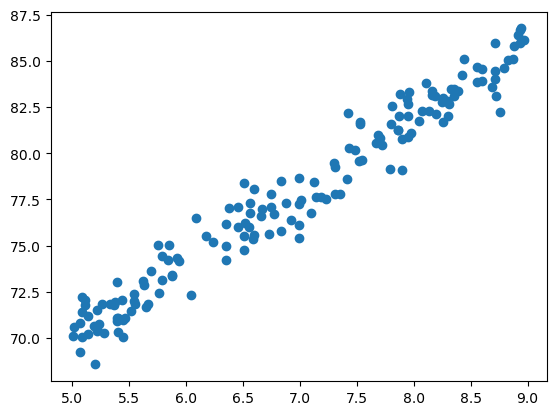

In [55]:
plt.scatter(X_train,y_train)

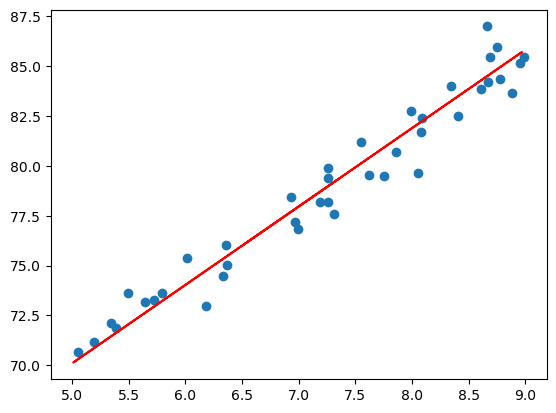

In [56]:
plt.scatter(X_test,y_test)
plt.plot(X_train,lr.predict(X_train),color="r")

# Save ML Model 

In [57]:
lr

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
import joblib 
joblib.dump(lr,"Desktop.pkl")

['Desktop.pkl']

In [59]:
pwd

'C:\\Users\\Dell\\Daily_Practice'

In [61]:
model = joblib.load("Desktop.pkl") #pickle


In [62]:
pwd

'C:\\Users\\Dell\\Daily_Practice'